# Model Prediction & Evaluation
### Breast Cancer Wisconsin Dataset — Logistic Regression Classifier

**What you'll do in this notebook:**
1. Split data and train a logistic regression model
2. Get prediction *probabilities* and turn them into class predictions
3. Build a confusion matrix and calculate evaluation metrics
4. Visualize the full trade-off space with ROC & PR curves
5. Deal with class imbalance using weighted metrics

> 💡 Along the way, we ask you to change numbers yourself and watch which effect that change had.


## 1. Setup

Run this once. If you're on a fresh environment, uncomment the install line.

In [1]:
# !pip install scikit-learn matplotlib numpy --quiet

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)

RANDOM_STATE = 42  # keep this fixed so everyone gets comparable results
np.random.seed(RANDOM_STATE)

## 2. Load Data & Train/Test Split

The dataset contains 30 numeric features describing cell nuclei, and a binary label:
`0 = malignant`, `1 = benign`.

We split into **train** (model learns from this) and **test** (we evaluate on this — the model never sees it during training). This is what makes our evaluation honest.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

print("Samples:", X.shape[0], "| Features:", X.shape[1])
print("Class counts -> malignant (0):", (y == 0).sum(), " benign (1):", (y == 1).sum())

Samples: 569 | Features: 30
Class counts -> malignant (0): 212  benign (1): 357


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,  # keep the same class ratio in both splits
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 426 | Test size: 143


**Note on `stratify=y`:** without it, a random split could accidentally put more malignant cases in one split than the other just by chance. Stratifying keeps the malignant/benign ratio consistent across train and test — important once we talk about class imbalance later.

We also scale the features. Logistic regression and MLPs are both sensitive to feature scale (unlike e.g. decision trees), so we standardize to mean 0 / std 1. We fit the scaler on the *training* data only, then apply it to both — fitting it on test data would leak information from the test set into training.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Train a Logistic Regression Model

Not the focus of this tutorial, but we need a trained model to evaluate. Logistic regression is the same kind of model you used for regression earlier, just applied to a classification problem — it outputs a probability instead of a continuous value.

In [5]:
logreg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
print("Logistic regression trained.")

Logistic regression trained.


**A second model, for later comparison:** we'll also fit a small multi-layer perceptron (MLP) — a small neural network. We won't walk through its confusion matrix or metrics individually (that would just repeat what we're about to do with logistic regression). We're training it now purely so that, once we reach the ROC/PR curves, we have a second line to compare against.

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16,),
    max_iter=2000,
    random_state=RANDOM_STATE,
)

mlp.fit(X_train_scaled, y_train)
print("Training done. Iterations used:", mlp.n_iter_)

Training done. Iterations used: 450


## 4. From Probabilities to Predictions

The model doesn't output classes directly — it outputs a **probability** for each class. `predict_proba` gives us, for every test sample, the probability of being malignant (column 0) and benign (column 1).

To turn a probability into an actual class prediction, we need a **decision threshold**: if `P(benign) >= threshold`, predict benign, otherwise predict malignant. The standard default is **0.5** — but that's a choice, not a law of nature.

In [7]:
# Probability of the POSITIVE class. We'll treat "benign" (1) as positive here,
# matching sklearn's default convention for binary labels {0, 1}.
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]  # P(benign)

# --- THE ONE NUMBER YOU'LL CHANGE LATER ---
THRESHOLD = 0.50
# -------------------------------------------

y_pred = (y_proba >= THRESHOLD).astype(int)

print("First 10 probabilities (P(benign)):", np.round(y_proba[:10], 2))
print("First 10 predictions   (0=malignant, 1=benign):", y_pred[:10])

First 10 probabilities (P(benign)): [0.97 0.   0.56 0.94 0.18 0.   0.   0.   0.   1.  ]
First 10 predictions   (0=malignant, 1=benign): [1 0 1 1 0 0 0 0 0 1]


## 5. Confusion Matrix

The confusion matrix counts how predictions line up with reality:

| | Predicted malignant | Predicted benign |
|---|---|---|
| **Actually malignant** | True Negative* | False Positive |
| **Actually benign** | False Negative* | True Positive |

*Naming depends on which class you call "positive" — we're treating **benign = positive**, so:
- **TP** = correctly predicted benign
- **TN** = correctly predicted malignant
- **FP** = predicted benign, but actually malignant ⚠️ *(dangerous: a sick patient sent home)*
- **FN** = predicted malignant, but actually benign *(safe-ish: a healthy patient gets extra tests)*

Confusion matrix:
[[52  1]
 [ 1 89]]

TN=52  FP=1  FN=1  TP=89


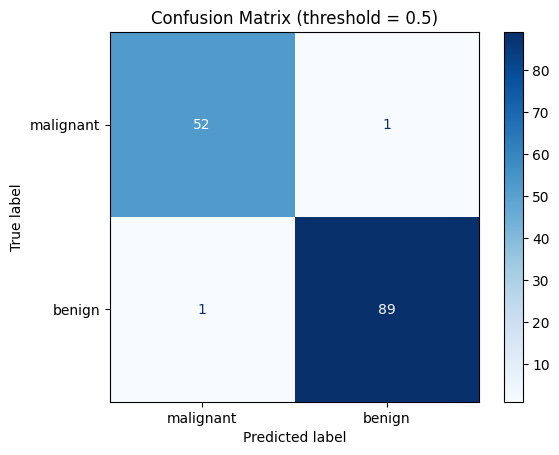

In [8]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion matrix:")
print(cm)
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")

ConfusionMatrixDisplay(cm, display_labels=["malignant", "benign"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold = {THRESHOLD})")
plt.show()

## 6. Calculating Evaluation Metrics

All of these come directly from the four numbers above. No magic, just arithmetic:

- **Accuracy** = $\dfrac{TP + TN}{TP+TN+FP+FN}$ — overall, how often is the model right?
- **Precision** = $\dfrac{TP}{TP+FP}$ — of everything predicted *benign*, how much really is?
- **Sensitivity / Recall** = $\dfrac{TP}{TP+FN}$ — of everything *actually* benign, how much did we catch?
  *(Yes — sensitivity and recall are the same thing, just different fields use different names: medicine says "sensitivity", ML papers usually say "recall".)*
- **F1 Score** = $2 \cdot \dfrac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ — harmonic mean of precision & recall, useful when you want one number balancing both.

In [9]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # = recall
f1 = (2 * precision * sensitivity / (precision + sensitivity)
      if (precision + sensitivity) > 0 else 0.0)

print(f"Threshold:          {THRESHOLD}")
print(f"Accuracy:            {accuracy:.3f}")
print(f"Precision:           {precision:.3f}")
print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"F1 Score:            {f1:.3f}")

Threshold:          0.5
Accuracy:            0.986
Precision:           0.989
Sensitivity (Recall): 0.989
F1 Score:            0.989


**Sanity check** — scikit-learn has built-in functions for all of these (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`). Feel free to import them and confirm your hand-calculated numbers match. We computed them manually first so the confusion-matrix connection is clear, not just a function call.

## 7. Change the Threshold

Before we go any further — go back to **Section 4**, change `THRESHOLD` to `0.8`, and re-run Sections 4, 5, and 6 (just those cells, top to bottom).

Watch what happens to precision and sensitivity/recall. Then try `0.2` and watch again.

Write down (mentally or in a comment) what you notice:
- Which metric went up, which went down?
- Did they move in the *same* direction, or opposite directions?
- What does lowering the threshold do to false negatives? Why might that matter more in a medical context than false positives — or does it?
- At what threshold would you personally be comfortable deploying this model, and why?

Once you've thought it through, set the threshold back to `0.5` and continue below — we're about to formalize exactly what you just observed.

## 8. ROC & PR Curves

You just saw it firsthand: change the threshold, and precision/recall move in opposite directions. Every metric in Section 6 is a snapshot at **one specific threshold**. So what if, instead of manually trying a few values, we computed those metrics at *every* threshold from 0 to 1 at once? Plotting that sweep gives us a curve — this is exactly the trade-off you just felt, now drawn out in full.

### ROC Curve
Plots **True Positive Rate** (= sensitivity/recall) against **False Positive Rate** ($\frac{FP}{FP+TN}$) at every threshold.
**AUC** (Area Under the Curve) compresses the whole curve into one number: the probability that a random benign case gets a higher predicted probability than a random malignant case. `0.5` = random guessing, `1.0` = perfect separation.

### Precision-Recall (PR) Curve
Plots **Precision** against **Recall** at every threshold — the exact two metrics you just watched trade off against each other. More informative than ROC when classes are imbalanced (more on that next section!), because it doesn't involve the (often huge) number of true negatives.

Both curves are **threshold-independent** — they tell you how good the model's probability ranking is, across every cutoff, not just the one you happened to try.

**Why two models on the same plot?** A single curve tells you "this model is good." Two curves on the same axes tell you "this model is better than that one, *and here's what that looks like*" — which is really the point of these plots: comparing models' ranking ability without committing to any one threshold. That's why we trained the MLP back in Section 3.

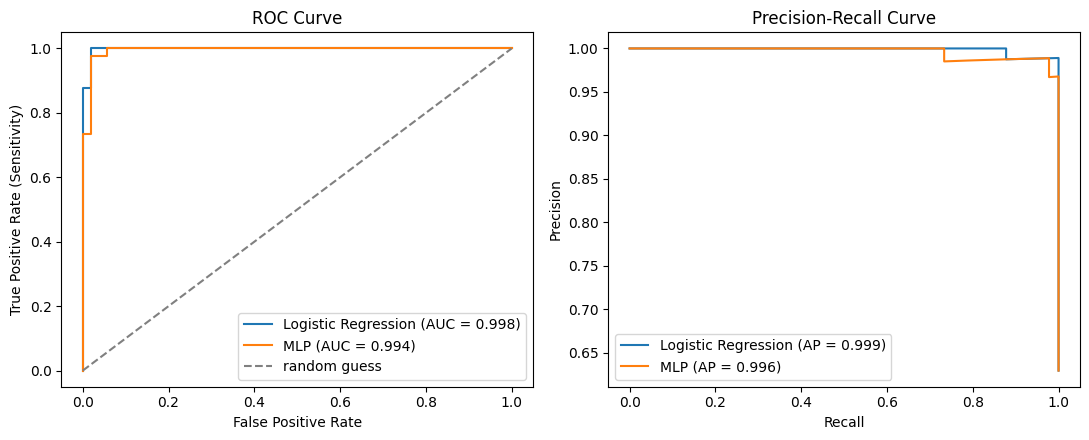

Logistic Regression  -> ROC AUC: 0.998 | Average Precision: 0.999
MLP                  -> ROC AUC: 0.994 | Average Precision: 0.996


In [10]:
mlp_proba = mlp.predict_proba(X_test_scaled)[:, 1]  # P(benign), second model

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_proba)
auc_score_mlp = roc_auc_score(y_test, mlp_proba)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)
precision_curve_mlp, recall_curve_mlp, _ = precision_recall_curve(y_test, mlp_proba)
ap_score_mlp = average_precision_score(y_test, mlp_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC
axes[0].plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
axes[0].plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {auc_score_mlp:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Sensitivity)")
axes[0].set_title("ROC Curve")
axes[0].legend()

# PR
axes[1].plot(recall_curve, precision_curve, label=f"Logistic Regression (AP = {ap_score:.3f})")
axes[1].plot(recall_curve_mlp, precision_curve_mlp, label=f"MLP (AP = {ap_score_mlp:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Logistic Regression  -> ROC AUC: {auc_score:.3f} | Average Precision: {ap_score:.3f}")
print(f"MLP                  -> ROC AUC: {auc_score_mlp:.3f} | Average Precision: {ap_score_mlp:.3f}")

**Reading these:** your current threshold corresponds to exactly *one point* on each Logistic Regression curve. Everything you computed by hand in Section 6 lives somewhere on those lines. Moving the threshold moves you along the curve — it doesn't change the curve itself, because the curve already reflects every possible threshold.

The MLP line is here purely as a reference: whichever curve sits closer to the top-right corner (and has the higher AUC/AP) is doing a better job separating the two classes overall — without us ever having to pick a threshold for it.

**Quick check:** if you still have a non-default `THRESHOLD` set from Section 7, look at the confusion matrix you got — could you point to roughly where on the ROC and PR curves above that result would sit? That's the connection between "one number you pick" and "the full curve".

## 9. Class Imbalance

Look back at the class counts from Section 2: malignant and benign aren't perfectly balanced (roughly 37% / 63%). This matters because **standard metrics can be misleading** when classes are imbalanced.

**Why?** Imagine a (bad) model that always predicts "benign", no matter the input. With our class split, it would still get ~63% accuracy — without learning anything. Accuracy alone can hide a model that's failing on the minority class entirely.

**The fix at evaluation time:** weighted metrics. Instead of one global score, compute the metric *per class*, then average — weighting each class either equally (`macro`) or by how many samples it has (`weighted`).

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print("Class balance in test set:")
print(" malignant:", (y_test == 0).sum(), f"({(y_test==0).mean():.1%})")
print(" benign:   ", (y_test == 1).sum(), f"({(y_test==1).mean():.1%})")
print()

# 'macro'    -> average metric per class, unweighted (treats classes as equally important)
# 'weighted' -> average metric per class, weighted by class size (accounts for imbalance)
precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

precision_weighted = precision_score(y_test, y_pred, average="weighted")
recall_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"{'Metric':<12}{'Macro avg':>12}{'Weighted avg':>15}")
print(f"{'Precision':<12}{precision_macro:>12.3f}{precision_weighted:>15.3f}")
print(f"{'Recall':<12}{recall_macro:>12.3f}{recall_weighted:>15.3f}")
print(f"{'F1':<12}{f1_macro:>12.3f}{f1_weighted:>15.3f}")

print("\nFull per-class report:")
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

Class balance in test set:
 malignant: 53 (37.1%)
 benign:    90 (62.9%)

Metric         Macro avg   Weighted avg
Precision          0.985          0.986
Recall             0.985          0.986
F1                 0.985          0.986

Full per-class report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



**One more lever (optional, just for awareness):** everything above fixes the imbalance problem *at evaluation time* — after the model is already trained. You can also address it *at training time* by passing `class_weight="balanced"` to many sklearn models, which tells the model to pay more attention to the minority class while learning. Different tool, same underlying problem.